In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv
/kaggle/input/datasets/akshatrajsingh1702/churn-csv/Churn_Modelling.csv


In [16]:
print ("hello world")

hello world


In [4]:
df=pd.read_csv('/kaggle/input/datasets/akshatrajsingh1702/churn-csv/Churn_Modelling.csv')

In [17]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6185,6186,15754526,Walker,699,Germany,Male,36,6,147137.74,1,1,1,33687.90,0
2690,2691,15754261,Ho,648,Spain,Male,42,2,98795.61,2,1,0,89123.99,0
9705,9706,15572374,Hopetoun,733,Spain,Male,36,1,0.00,2,0,1,108377.82,0
8371,8372,15661034,Ngozichukwuka,813,Germany,Female,29,5,106059.40,1,0,0,187976.88,1
637,638,15583725,Mairinger,682,France,Male,48,1,138778.15,1,0,1,168840.23,0


In [6]:
df.info

<bound method DataFrame.info of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfP

In [18]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [19]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [20]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

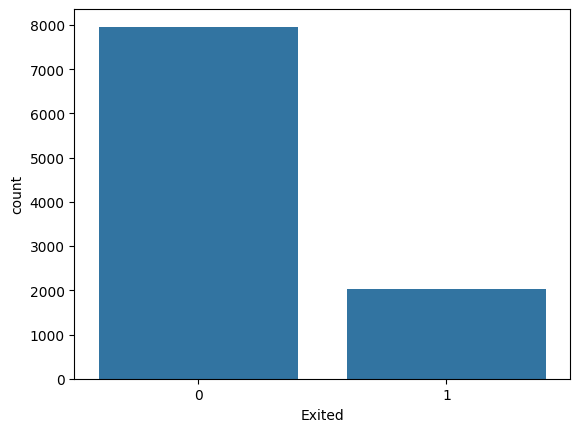

In [23]:
sns.countplot(x='Exited', data=df)
plt.show()

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


In [25]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [26]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [27]:
df.select_dtypes(include='object').columns

Index(['Geography', 'Gender'], dtype='object')

In [31]:
df = pd.get_dummies(df, drop_first=True)

In [32]:
df.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
5690,577,39,4,0.00,2,1,0,91366.42,0,False,True,False
2396,600,27,3,0.00,2,0,1,125698.97,0,False,False,False
7199,649,32,7,0.00,1,1,0,28797.32,0,False,True,False
312,642,38,3,0.00,2,0,0,171463.83,0,False,False,True
7726,735,55,6,134140.68,1,1,0,2267.88,0,False,False,True


In [35]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [92]:
y_pred = lr.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

0.808
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [42]:
print(accuracy_score(y_test, y_pred))

0.808


<Axes: xlabel='Exited', ylabel='Age'>

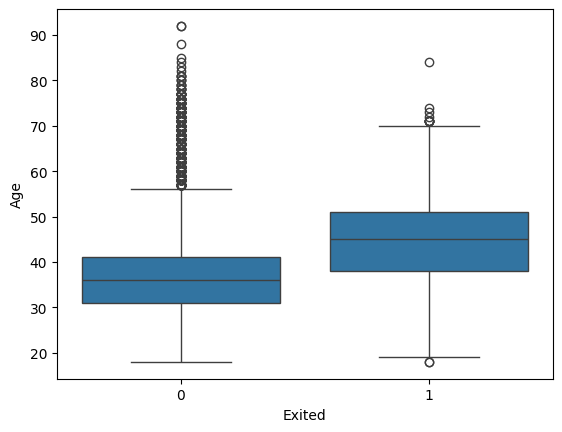

In [43]:
sns.boxplot(x='Exited', y='Age', data=df)

<Axes: xlabel='Exited', ylabel='Balance'>

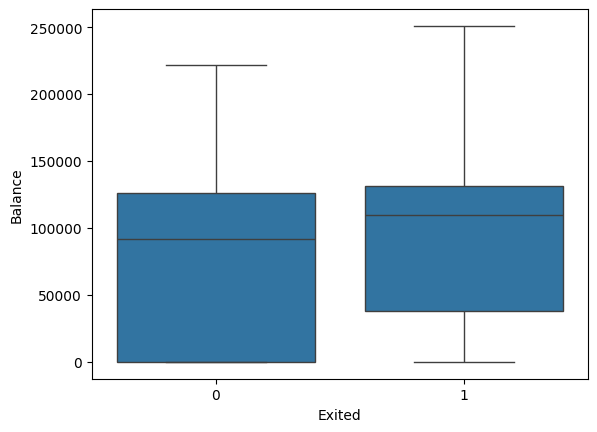

In [45]:
sns.boxplot(x='Exited', y='Balance', data=df)

<Axes: xlabel='IsActiveMember', ylabel='count'>

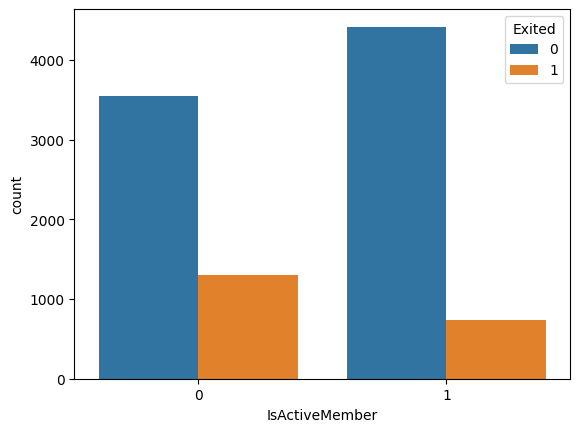

In [46]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1540   53]
 [ 331   76]]


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [94]:
lr1 = LogisticRegression(class_weight='balanced')

lr1.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [95]:
y_pred1 = lr1.predict(X_test)

In [96]:
print(accuracy_score(y_test, y_pred1))

print(classification_report(y_test, y_pred1))

0.7135
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

In [61]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200,
                       random_state=42)

In [64]:
y_pred_rf = rf.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

0.826
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      1593
           1       0.56      0.71      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.83      2000

[[1362  231]
 [ 117  290]]


In [66]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
1,Age,0.352674
4,NumOfProducts,0.249521
3,Balance,0.103700
8,Geography_Germany,0.065073
6,IsActiveMember,0.061783
0,CreditScore,0.052160
7,EstimatedSalary,0.051852
2,Tenure,0.027485
10,Gender_Male,0.022615
9,Geography_Spain,0.006894


In [67]:
from xgboost import XGBClassifier

In [68]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    random_state=42
)

In [71]:
scale_pos_weight=4

In [72]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [73]:
y_pred_xgb = xgb.predict(X_test)

In [74]:
print(classification_report(y_test, y_pred_xgb))

print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.71      0.62       407

    accuracy                           0.82      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.85      0.82      0.83      2000

[[1363  230]
 [ 120  287]]


In [75]:
print(accuracy_score(y_test, y_pred_xgb))

0.825


In [99]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]

roc_lr = roc_auc_score(y_test, y_prob)

print("Logistic Regression ROC-AUC:", roc_lr)

Logistic Regression ROC-AUC: 0.7747778595236223


In [98]:
y_prob_bal = lr1.predict_proba(X_test)[:,1]

roc_bal = roc_auc_score(y_test, y_prob_bal)

print("Balanced Logistic Regression ROC-AUC:", roc_bal)

Balanced Logistic Regression ROC-AUC: 0.7771376923919298


In [87]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.8658674082402896


In [88]:
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

roc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost ROC-AUC:", roc_xgb)

XGBoost ROC-AUC: 0.8525598017123441


In [97]:
print(lr)
print(lr1)

LogisticRegression()
LogisticRegression(class_weight='balanced')


In [100]:
y_pred = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.808


In [101]:
y_pred_bal = lr1.predict(X_test)

acc_bal = accuracy_score(y_test, y_pred_bal)

print("Balanced Logistic Regression Accuracy:", acc_bal)

Balanced Logistic Regression Accuracy: 0.7135


In [102]:
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.826


In [103]:
y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)

XGBoost Accuracy: 0.825


In [106]:
recall_lr = recall_score(y_test, y_pred)

f1_lr = f1_score(y_test, y_pred)

print("LR Recall:", recall_lr)
print("LR F1-Score:", f1_lr)

LR Recall: 0.18673218673218672
LR F1-Score: 0.2835820895522388


In [105]:
from sklearn.metrics import recall_score, f1_score

In [107]:
recall_bal = recall_score(y_test, y_pred_bal)

f1_bal = f1_score(y_test, y_pred_bal)

print("Balanced LR Recall:", recall_bal)
print("Balanced LR F1-Score:", f1_bal)

Balanced LR Recall: 0.7002457002457002
Balanced LR F1-Score: 0.49868766404199477


In [108]:
recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

print("RF Recall:", recall_rf)
print("RF F1-Score:", f1_rf)

RF Recall: 0.7125307125307125
RF F1-Score: 0.625


In [109]:
recall_xgb = recall_score(y_test, y_pred_xgb)

f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGB Recall:", recall_xgb)
print("XGB F1-Score:", f1_xgb)

XGB Recall: 0.7051597051597052
XGB F1-Score: 0.6212121212121212


In [110]:
import shap

In [111]:
explainer = shap.TreeExplainer(rf)

In [112]:
shap_values = explainer.shap_values(X_test)

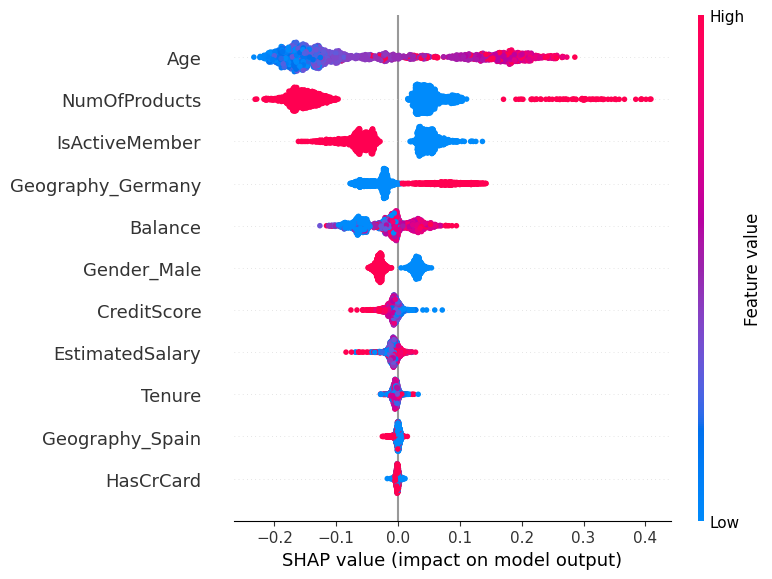

In [116]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    feature_names=X.columns
)